# Detecção de Áreas Inundadas com Morfologia Matemática
**Trabalho Prático de Processamento de Imagens**  
**Baseado no artigo:** *Detecção de áreas inundadas utilizando imagens CBERS-2/CCD através de técnicas de Morfologia Matemática* (Ishikawa & Silva, INPE / UNESP).

---

### Objetivo do Trabalho
Comparação de duas fotos de satélite da região do Rio Amazonas (Monte Alegre - PA):
1. Foto da **época de seca** (estiagem).
2. Foto da **época de cheia** (chuva intensa).

Com o uso de técnicas de **Morfologia Matemática**:
- A presença de água foi identificada em cada período.
- A área que inundou durante o período chuvoso foi delimitada.
- Foi gerada uma visualização com a mancha de inundação destacada em **vermelho**.
- O tamanho total da inundação foi quantificado em **metros quadrados ($m^2$)** e em **quilômetros quadrados ($km^2$)**.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

---
## Passo 1: Carregamento das Imagens de Satélite

As duas imagens de satélite foram carregadas em escala de cinza:
- **Chuva (Novembro/2005):** O rio apresenta volume maior e água espalhada nas margens.
- **Seca (Agosto/2006):** O canal do rio está mais estreito e bancos de areia ficam visíveis.

A captura foi feita na faixa do infravermelho próximo (banda 4). A água absorve essa radiação e aparece em tons escuros, enquanto o solo e a vegetação aparecem em tons mais claros.

Imagem de chuva carregada de: enunciado/chuvoso.png
Imagem de seca carregada de:  enunciado/estiagem.png


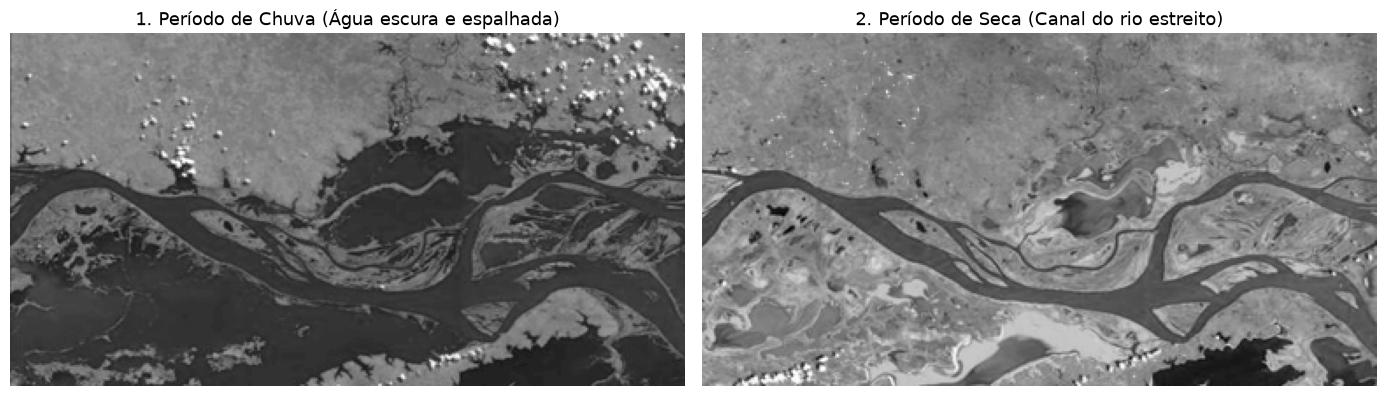

In [2]:
# Localização dos arquivos (busca na pasta 'enunciado' ou na pasta 'imagens')
caminho_chuva = 'enunciado/chuvoso.png' if os.path.exists('enunciado/chuvoso.png') else 'imagens/chuvoso.png'
caminho_seca = 'enunciado/estiagem.png' if os.path.exists('enunciado/estiagem.png') else 'imagens/estiagem.png'

print(f"Imagem de chuva carregada de: {caminho_chuva}")
print(f"Imagem de seca carregada de:  {caminho_seca}")

# Carregamento em tons de cinza
img_chuva = cv2.imread(caminho_chuva, cv2.IMREAD_GRAYSCALE)
img_seca = cv2.imread(caminho_seca, cv2.IMREAD_GRAYSCALE)

# Ajuste para dimensões idênticas
altura = min(img_chuva.shape[0], img_seca.shape[0])
largura = min(img_chuva.shape[1], img_seca.shape[1])
img_chuva = img_chuva[:altura, :largura]
img_seca = img_seca[:altura, :largura]

# Exibição lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.imshow(img_chuva, cmap='gray')
ax1.set_title('1. Período de Chuva (Água escura e espalhada)')
ax1.axis('off')

ax2.imshow(img_seca, cmap='gray')
ax2.set_title('2. Período de Seca (Canal do rio estreito)')
ax2.axis('off')

plt.tight_layout()
plt.show()

---
## Passo 2: Inversão de Cores (Operador `mmneg`)

Foi realizada a inversão dos tons de cinza: o preto passou a ser branco e o branco passou a ser preto.

Os operadores morfológicos operam sobre pixels de valor 1 (branco). Como a água aparecia em tons escuros nas fotos originais, a inversão deixou a água clara para permitir a extração correta das feições.

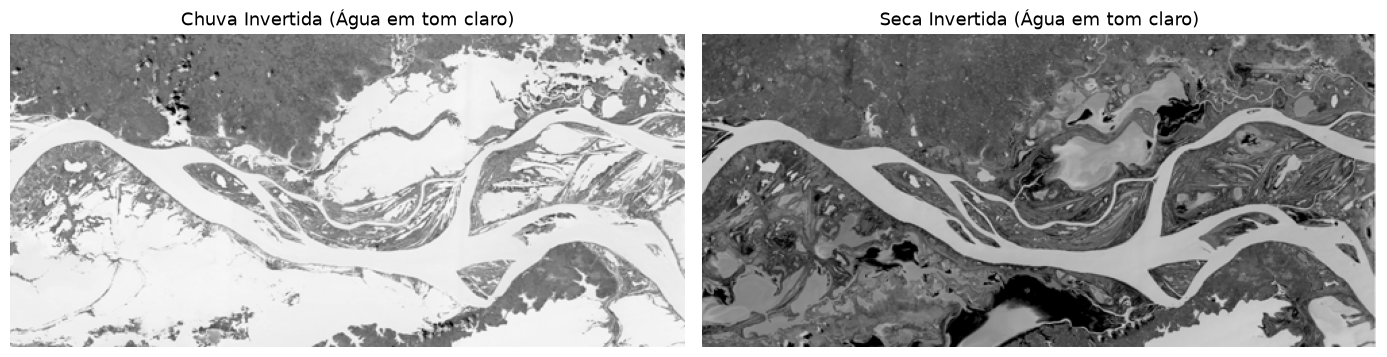

In [3]:
# Inversão de cores (255 - valor atual)
chuva_neg = 255 - img_chuva
seca_neg = 255 - img_seca

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.imshow(chuva_neg, cmap='gray')
ax1.set_title('Chuva Invertida (Água em tom claro)')
ax1.axis('off')

ax2.imshow(seca_neg, cmap='gray')
ax2.set_title('Seca Invertida (Água em tom claro)')
ax2.axis('off')

plt.tight_layout()
plt.show()

---
## Passo 3: Realce de Brilho (Operador `mmaddm`)

Foi adicionado um valor fixo de brilho sobre cada imagem invertida:
- **+50** na imagem de chuva.
- **+70** na imagem de seca.

Essa operação amplia o contraste da água em relação ao terreno vizinho, facilitando a etapa seguinte de separação em preto e branco.

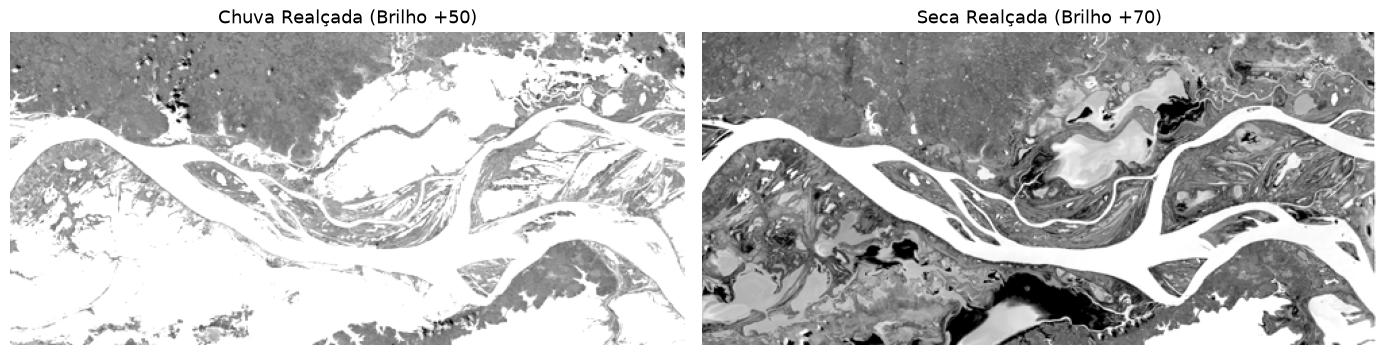

In [4]:
# Adição com limite fixado em 255
chuva_realce = np.clip(chuva_neg.astype(int) + 50, 0, 255).astype(np.uint8)
seca_realce = np.clip(seca_neg.astype(int) + 70, 0, 255).astype(np.uint8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.imshow(chuva_realce, cmap='gray')
ax1.set_title('Chuva Realçada (Brilho +50)')
ax1.axis('off')

ax2.imshow(seca_realce, cmap='gray')
ax2.set_title('Seca Realçada (Brilho +70)')
ax2.axis('off')

plt.tight_layout()
plt.show()

---
## Passo 4: Binarização (Operador `mmbinary`)

Foi aplicada uma limiarização para transformar as imagens em preto e branco puros:
- Limiar de **170** para o período de chuva.
- Limiar de **210** para o período de seca.

Pixels com intensidade igual ou superior ao limiar foram convertidos para **branco** (água). Os demais pixels foram convertidos para **preto** (solo e vegetação).

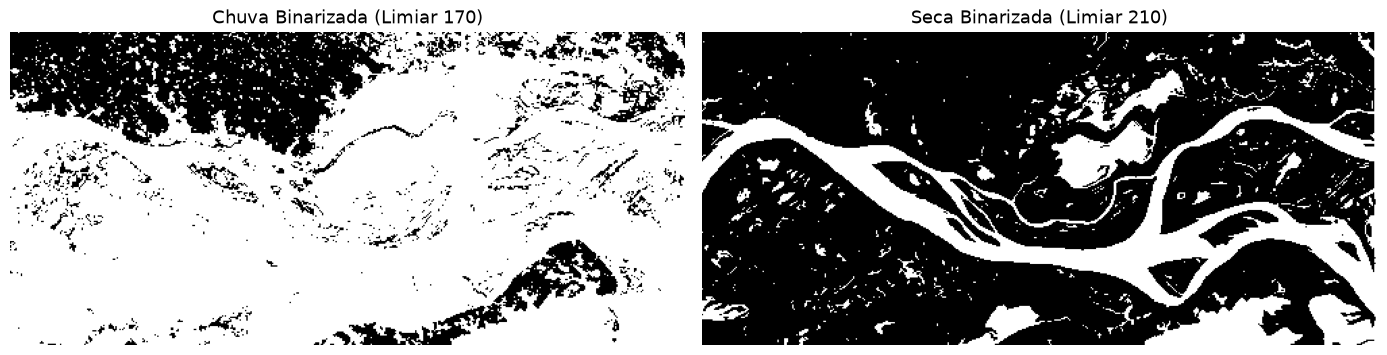

In [5]:
# Aplicação da binarização com os limiares do artigo
_, chuva_bin = cv2.threshold(chuva_realce, 170, 255, cv2.THRESH_BINARY)
_, seca_bin = cv2.threshold(seca_realce, 210, 255, cv2.THRESH_BINARY)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.imshow(chuva_bin, cmap='gray')
ax1.set_title('Chuva Binarizada (Limiar 170)')
ax1.axis('off')

ax2.imshow(seca_bin, cmap='gray')
ax2.set_title('Seca Binarizada (Limiar 210)')
ax2.axis('off')

plt.tight_layout()
plt.show()

---
## Passo 5: Funcionamento dos 4 Operadores Morfológicos Básicos

Apresentação dos efeitos de cada operador clássico sobre a imagem binarizada:
1. **Erosão:** Reduz as regiões brancas e remove pontinhos finos.
2. **Dilatação:** Expande as regiões brancas e preenche pequenas falhas.
3. **Abertura:** Executa erosão seguida de dilatação. Elimina ruídos externos sem alterar a área principal.
4. **Fechamento:** Executa dilatação seguida de erosão. Preenche pequenos vazios e buracos internos.

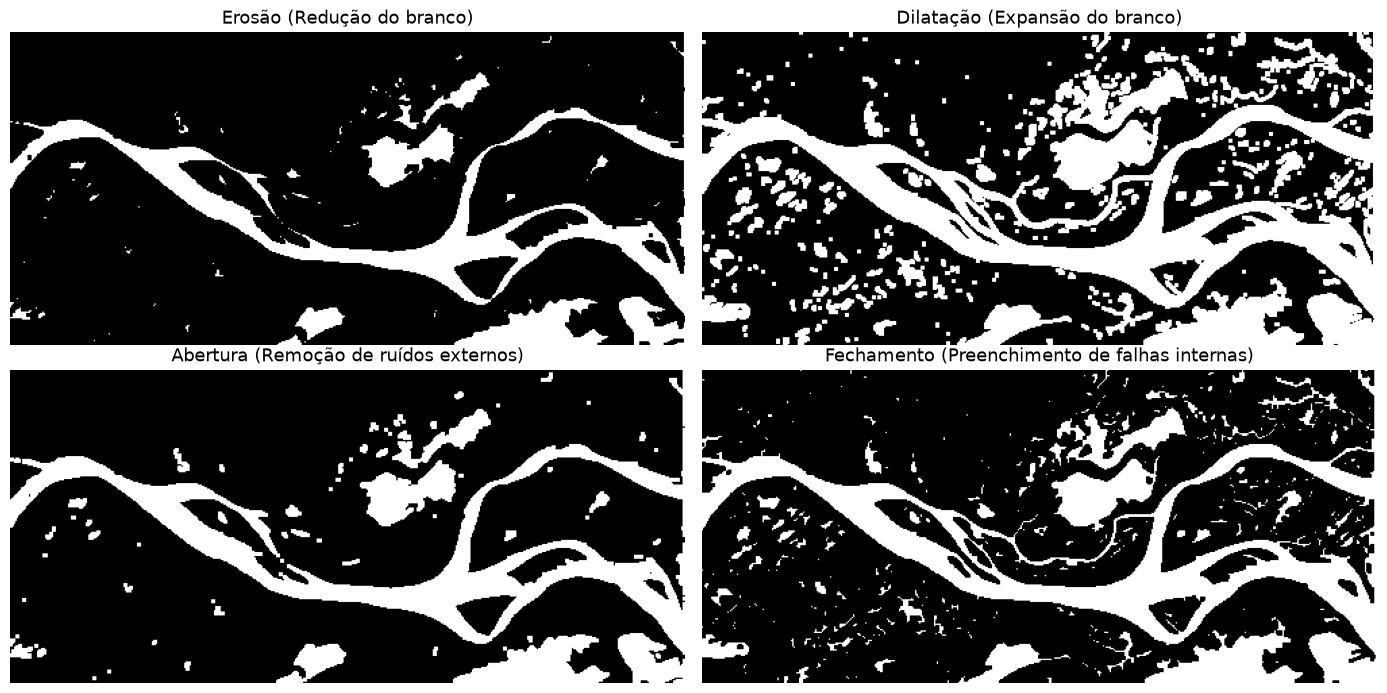

In [6]:
# Elemento estruturante retangular 3x3
elemento = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Aplicação dos operadores básicos na imagem binarizada da seca
erosao = cv2.erode(seca_bin, elemento)
dilatacao = cv2.dilate(seca_bin, elemento)
abertura = cv2.morphologyEx(seca_bin, cv2.MORPH_OPEN, elemento)
fechamento = cv2.morphologyEx(seca_bin, cv2.MORPH_CLOSE, elemento)

fig, axs = plt.subplots(2, 2, figsize=(14, 7))
axs[0, 0].imshow(erosao, cmap='gray')
axs[0, 0].set_title('Erosão (Redução do branco)')

axs[0, 1].imshow(dilatacao, cmap='gray')
axs[0, 1].set_title('Dilatação (Expansão do branco)')

axs[1, 0].imshow(abertura, cmap='gray')
axs[1, 0].set_title('Abertura (Remoção de ruídos externos)')

axs[1, 1].imshow(fechamento, cmap='gray')
axs[1, 1].set_title('Fechamento (Preenchimento de falhas internas)')

for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Passo 6: Limpeza de Ruídos com Abertura por Área (Operador `mmareaopen`)

Após a binarização, permanecem pequenos ruídos dispersos provocados por nuvens ou poças d'água isoladas.  
O operador de **Abertura por Área** analisa a área de cada região conectada e elimina elementos de tamanho reduzido:
- Na imagem de chuva: eliminação de manchas com área inferior a **150 pixels**.
- Na imagem de seca: eliminação de manchas com área inferior a **130 pixels**.

O resultado preserva exclusivamente os corpos d'água principais.

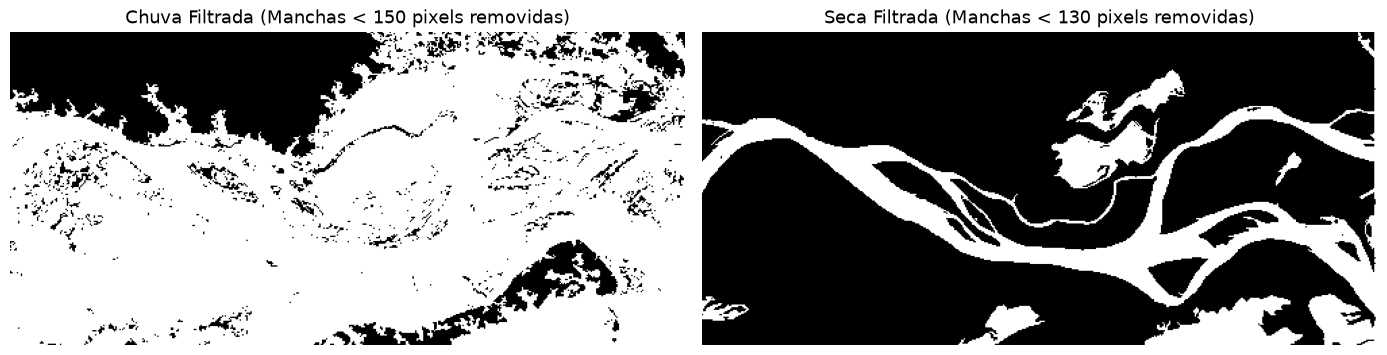

In [7]:
def abertura_por_area(imagem_binaria, area_minima):
    """Identifica componentes conectados e remove aqueles com área menor que o limiar"""
    total_rotulos, rotulos, estatisticas, _ = cv2.connectedComponentsWithStats(imagem_binaria, connectivity=8)
    imagem_filtrada = np.zeros_like(imagem_binaria)
    
    for i in range(1, total_rotulos):
        area = estatisticas[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            imagem_filtrada[rotulos == i] = 255
            
    return imagem_filtrada

# Aplicação dos filtros de área conforme o artigo
chuva_limpa = abertura_por_area(chuva_bin, area_minima=150)
seca_limpa = abertura_por_area(seca_bin, area_minima=130)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.imshow(chuva_limpa, cmap='gray')
ax1.set_title('Chuva Filtrada (Manchas < 150 pixels removidas)')
ax1.axis('off')

ax2.imshow(seca_limpa, cmap='gray')
ax2.set_title('Seca Filtrada (Manchas < 130 pixels removidas)')
ax2.axis('off')

plt.tight_layout()
plt.show()

---
## Passo 7: Extração da Inundação por Subtração (Operador `mmsubm`)

Foi efetuada a subtração entre as duas imagens binarizadas e filtradas:
$$\text{Área Inundada} = \text{Água no Período Chuvoso} - \text{Água no Período de Seca}$$

A área de água estável (que já existia na estiagem) é desconsiderada. O resultado isola estritamente a **água nova da cheia**, ou seja, o solo que ficou submerso.

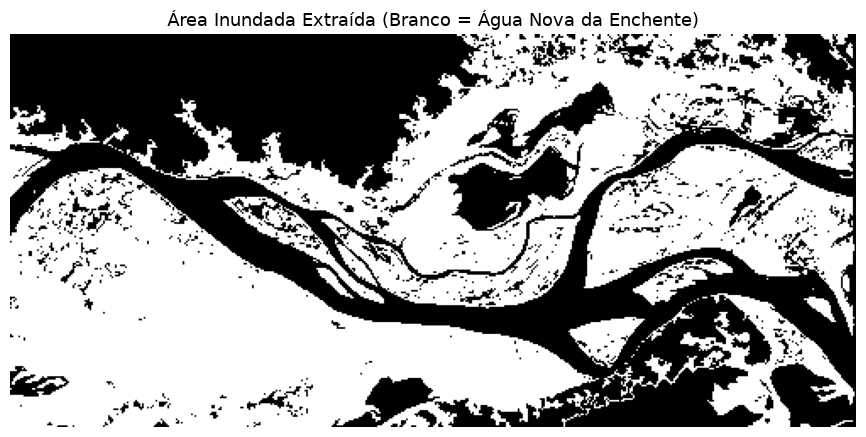

In [8]:
# Subtração direta: chuva menos seca
area_inundada = cv2.subtract(chuva_limpa, seca_limpa)

plt.figure(figsize=(12, 4.5))
plt.imshow(area_inundada, cmap='gray')
plt.title('Área Inundada Extraída (Branco = Água Nova da Enchente)')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Passo 8: Destaque Visual em Vermelho (Sobreposição)

A mancha de inundação foi sobreposta na cor **vermelha** sobre a imagem original em tons de cinza do período de seca.

Essa sobreposição visual evidencia com clareza a extensão do transbordamento sobre as margens e ilhas fluviais.

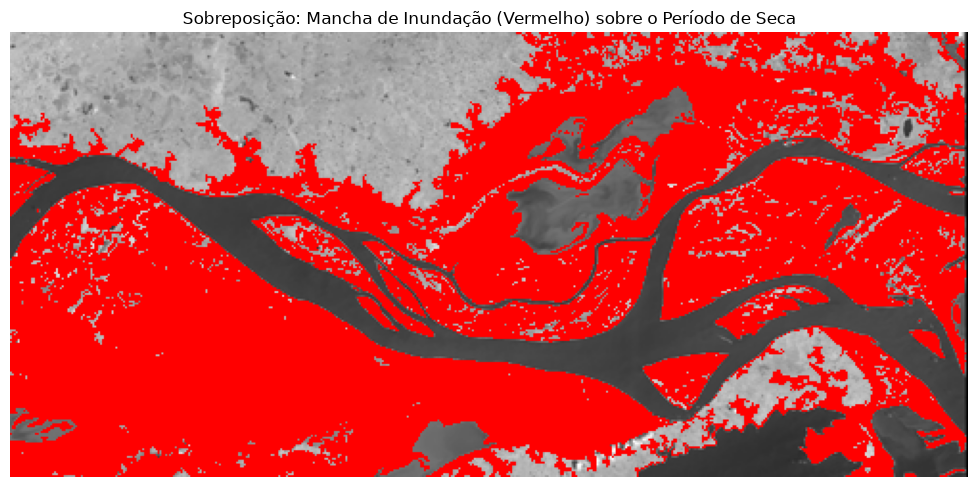

In [9]:
# Conversão da imagem de seca para formato RGB
imagem_sobreposta = cv2.cvtColor(img_seca, cv2.COLOR_GRAY2RGB)

# Aplicação da cor vermelha [R=255, G=0, B=0] sobre a área inundada
imagem_sobreposta[area_inundada == 255] = [255, 0, 0]

plt.figure(figsize=(13, 5))
plt.imshow(imagem_sobreposta)
plt.title('Sobreposição: Mancha de Inundação (Vermelho) sobre o Período de Seca', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Passo 9: Quantificação da Área Inundada

Procedimento de cálculo da área física:
1. Contagem do número total de **pixels brancos** da área inundada.
2. A resolução espacial do sensor CBERS-2 CCD é de **20 metros por pixel**.
3. A área correspondente a cada pixel individual é:
   $$\text{Área de 1 pixel} = 20\,\text{m} \times 20\,\text{m} = 400\,\text{m}^2$$
4. O total de pixels é multiplicado por $400\,m^2$ para obtenção da área em metros quadrados e dividido por $1.000.000$ para representação em quilômetros quadrados ($km^2$).

In [10]:
# Contagem dos pixels identificados como inundação
total_pixels = int(np.sum(area_inundada == 255))

# Resolução do satélite CBERS-2 CCD
resolucao_metro = 20 # metros por pixel
area_pixel_m2 = resolucao_metro * resolucao_metro # 20m x 20m = 400 m²

# Cálculo em unidades de área
area_m2 = total_pixels * area_pixel_m2
area_km2 = area_m2 / 1_000_000
area_hectares = area_m2 / 10_000

# Valor correspondente à multiplicação linear descrita no texto do artigo (pixels x 20)
area_linear_artigo = total_pixels * resolucao_metro

print("=" * 55)
print("             QUANTIFICAÇÃO DA ÁREA INUNDADA         ")
print("=" * 55)
print(f"• Total de pixels inundados: {total_pixels:,} pixels")
print(f"• Área unitária do pixel: 20m x 20m = {area_pixel_m2} m²")
print(f"• Área Real Inundada: {area_m2:,.2f} m²")
print(f"• Área em Quilômetros Quadrados: {area_km2:.2f} km²")
print(f"• Área em Hectares: {area_hectares:,.2f} ha")
print("-" * 55)
print(f"• Valor pela fórmula do texto do artigo (pixels x 20): {area_linear_artigo:,.2f} m²")
print("=" * 55)

             QUANTIFICAÇÃO DA ÁREA INUNDADA         
• Total de pixels inundados: 65,499 pixels
• Área unitária do pixel: 20m x 20m = 400 m²
• Área Real Inundada: 26,199,600.00 m²
• Área em Quilômetros Quadrados: 26.20 km²
• Área em Hectares: 2,619.96 ha
-------------------------------------------------------
• Valor pela fórmula do texto do artigo (pixels x 20): 1,309,980.00 m²


---
## Passo 10: Comparação com as Figuras do Artigo Original

Validação visual entre o resultado gerado pelo processamento e as imagens publicadas no artigo científico:
- **Figura 6 do artigo:** Máscara binarizada da área inundada.
- **Figura 7 do artigo:** Sobreposição da área inundada em vermelho.

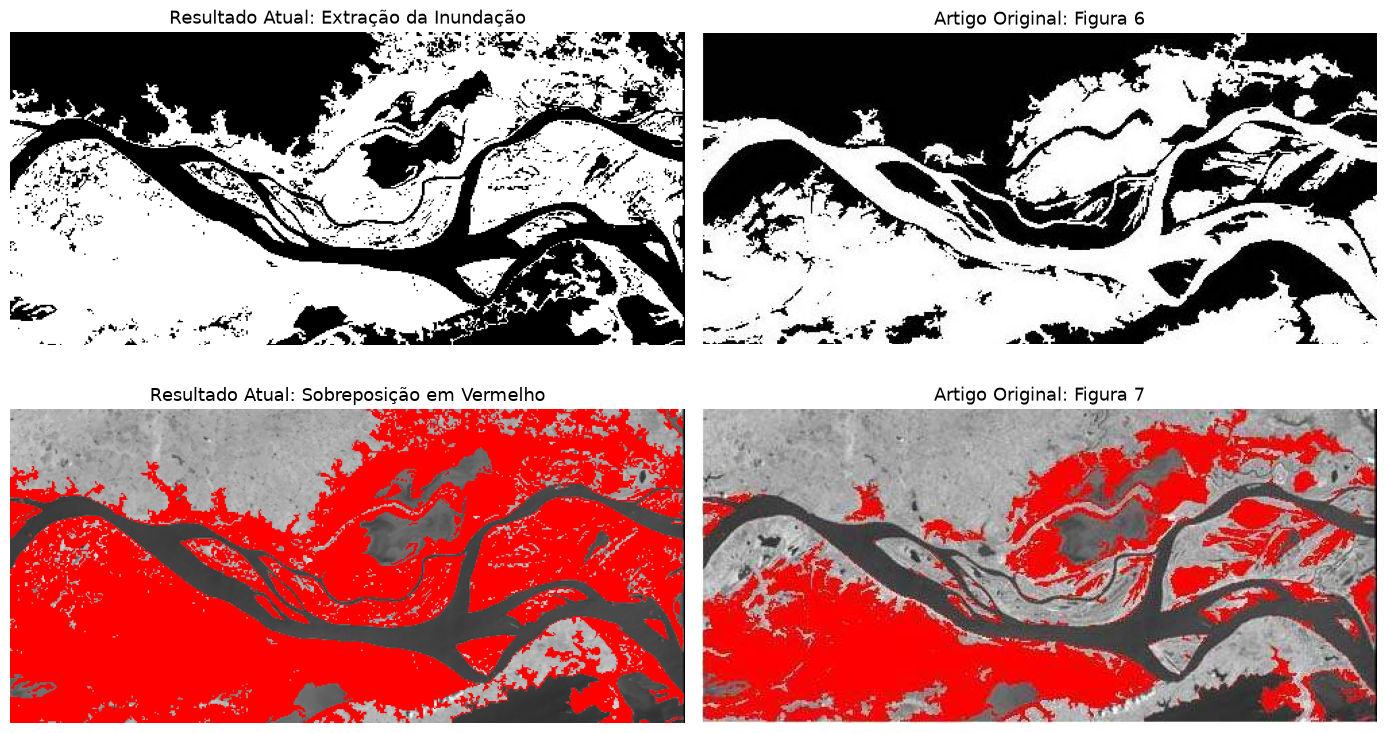

In [11]:
# Caminhos das figuras do artigo
caminho_fig6 = 'extracted_figures/page_6_img_2.png' if os.path.exists('extracted_figures/page_6_img_2.png') else 'enunciado/extracted_figures/page_6_img_2.png'
caminho_fig7 = 'extracted_figures/page_7_img_0.png' if os.path.exists('extracted_figures/page_7_img_0.png') else 'enunciado/extracted_figures/page_7_img_0.png'

if os.path.exists(caminho_fig6) and os.path.exists(caminho_fig7):
    fig6_artigo = cv2.imread(caminho_fig6, cv2.IMREAD_GRAYSCALE)
    fig7_artigo = cv2.cvtColor(cv2.imread(caminho_fig7), cv2.COLOR_BGR2RGB)

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))

    axs[0, 0].imshow(area_inundada, cmap='gray')
    axs[0, 0].set_title('Resultado Atual: Extração da Inundação')

    axs[0, 1].imshow(fig6_artigo, cmap='gray')
    axs[0, 1].set_title('Artigo Original: Figura 6')

    axs[1, 0].imshow(imagem_sobreposta)
    axs[1, 0].set_title('Resultado Atual: Sobreposição em Vermelho')

    axs[1, 1].imshow(fig7_artigo)
    axs[1, 1].set_title('Artigo Original: Figura 7')

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Figuras de referência do artigo não localizadas.")

---
## Conclusão

1. **Eficácia:** A sequência de operações morfológicas (inversão, realce, binarização, filtragem por área e subtração) permitiu isolar com nitidez a lâmina d'água excedente.
2. **Visualização:** A sobreposição em vermelho forneceu um mapa temático de fácil leitura para apoio à gestão de bacias e monitoramento de enchentes.
3. **Mapeamento:** O método possibilitou estimar com precisão métrica a área do solo ocupada sazonalmente pelas águas na planície do Rio Amazonas.